# 07 – Decision Tree

Review 1 Part-A classification.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from classification_utils import (
    load_data,
    prepare_target,
    make_split,
    make_preprocessor,
    make_pipeline
)

# Load dataset
df, feature_cols = prepare_target(
    load_data()
)

# Stratified 80:20 train-test split
X_train, X_test, y_train, y_test, le = make_split(
    df,
    feature_cols
)

# Preprocessing
preprocessor = make_preprocessor(
    X_train
)

# Decision Tree model
model = DecisionTreeClassifier(
    random_state=42
)

# Complete preprocessing + model pipeline
pipe = make_pipeline(
    model,
    preprocessor
)

# Train
pipe.fit(
    X_train,
    y_train
)

# Predictions
y_pred = pipe.predict(
    X_test
)

# Evaluation metrics
metrics = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(
        y_test,
        y_pred
    ),
    "Precision": precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )
}

# Display metrics
results = pd.DataFrame([metrics])

display(
    results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)

# Classification report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        zero_division=0
    )
)

,Model,Accuracy,Precision,Recall,Weighted F1
0,Decision Tree,0.6967,0.7051,0.6967,0.6986


Classification Report:
              precision    recall  f1-score   support

       Bumps       0.57      0.62      0.59        81
   Dirtiness       0.58      0.64      0.61        11
    K_Scatch       0.99      0.86      0.92        78
Other_Faults       0.66      0.72      0.69       135
      Pastry       0.48      0.38      0.42        32
      Stains       0.92      0.79      0.85        14
   Z_Scratch       0.73      0.71      0.72        38

    accuracy                           0.70       389
   macro avg       0.70      0.67      0.68       389
weighted avg       0.71      0.70      0.70       389



## Confusion Matrix

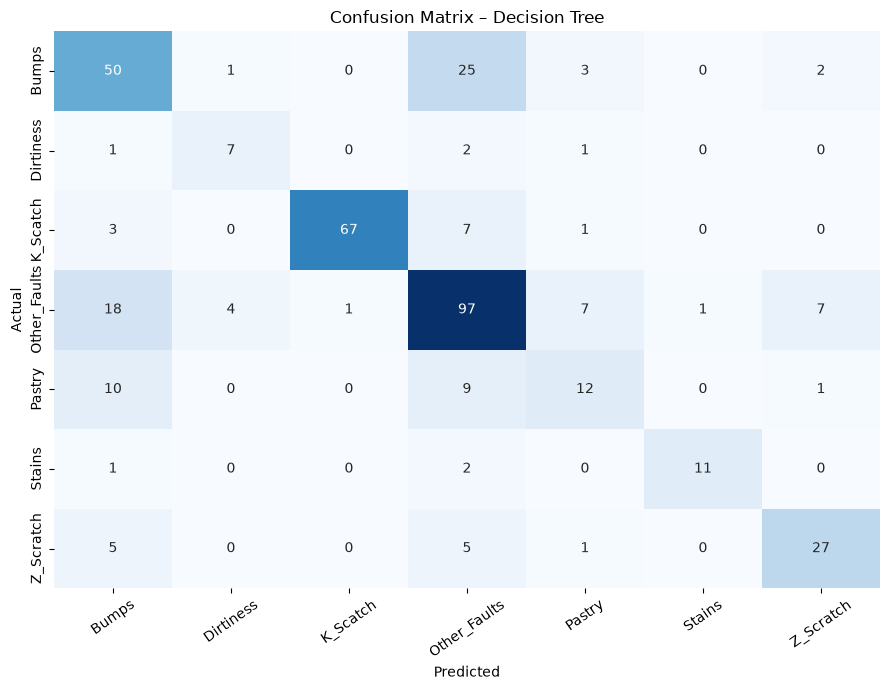

In [3]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix – Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

### Observation

The diagonal cells of the confusion matrix represent correct predictions, while off-diagonal cells represent fault-type confusions. The Accuracy, weighted Precision, weighted Recall and weighted F1 values above summarise the model's performance on the same held-out test set.

## Decision-Tree Visualisation

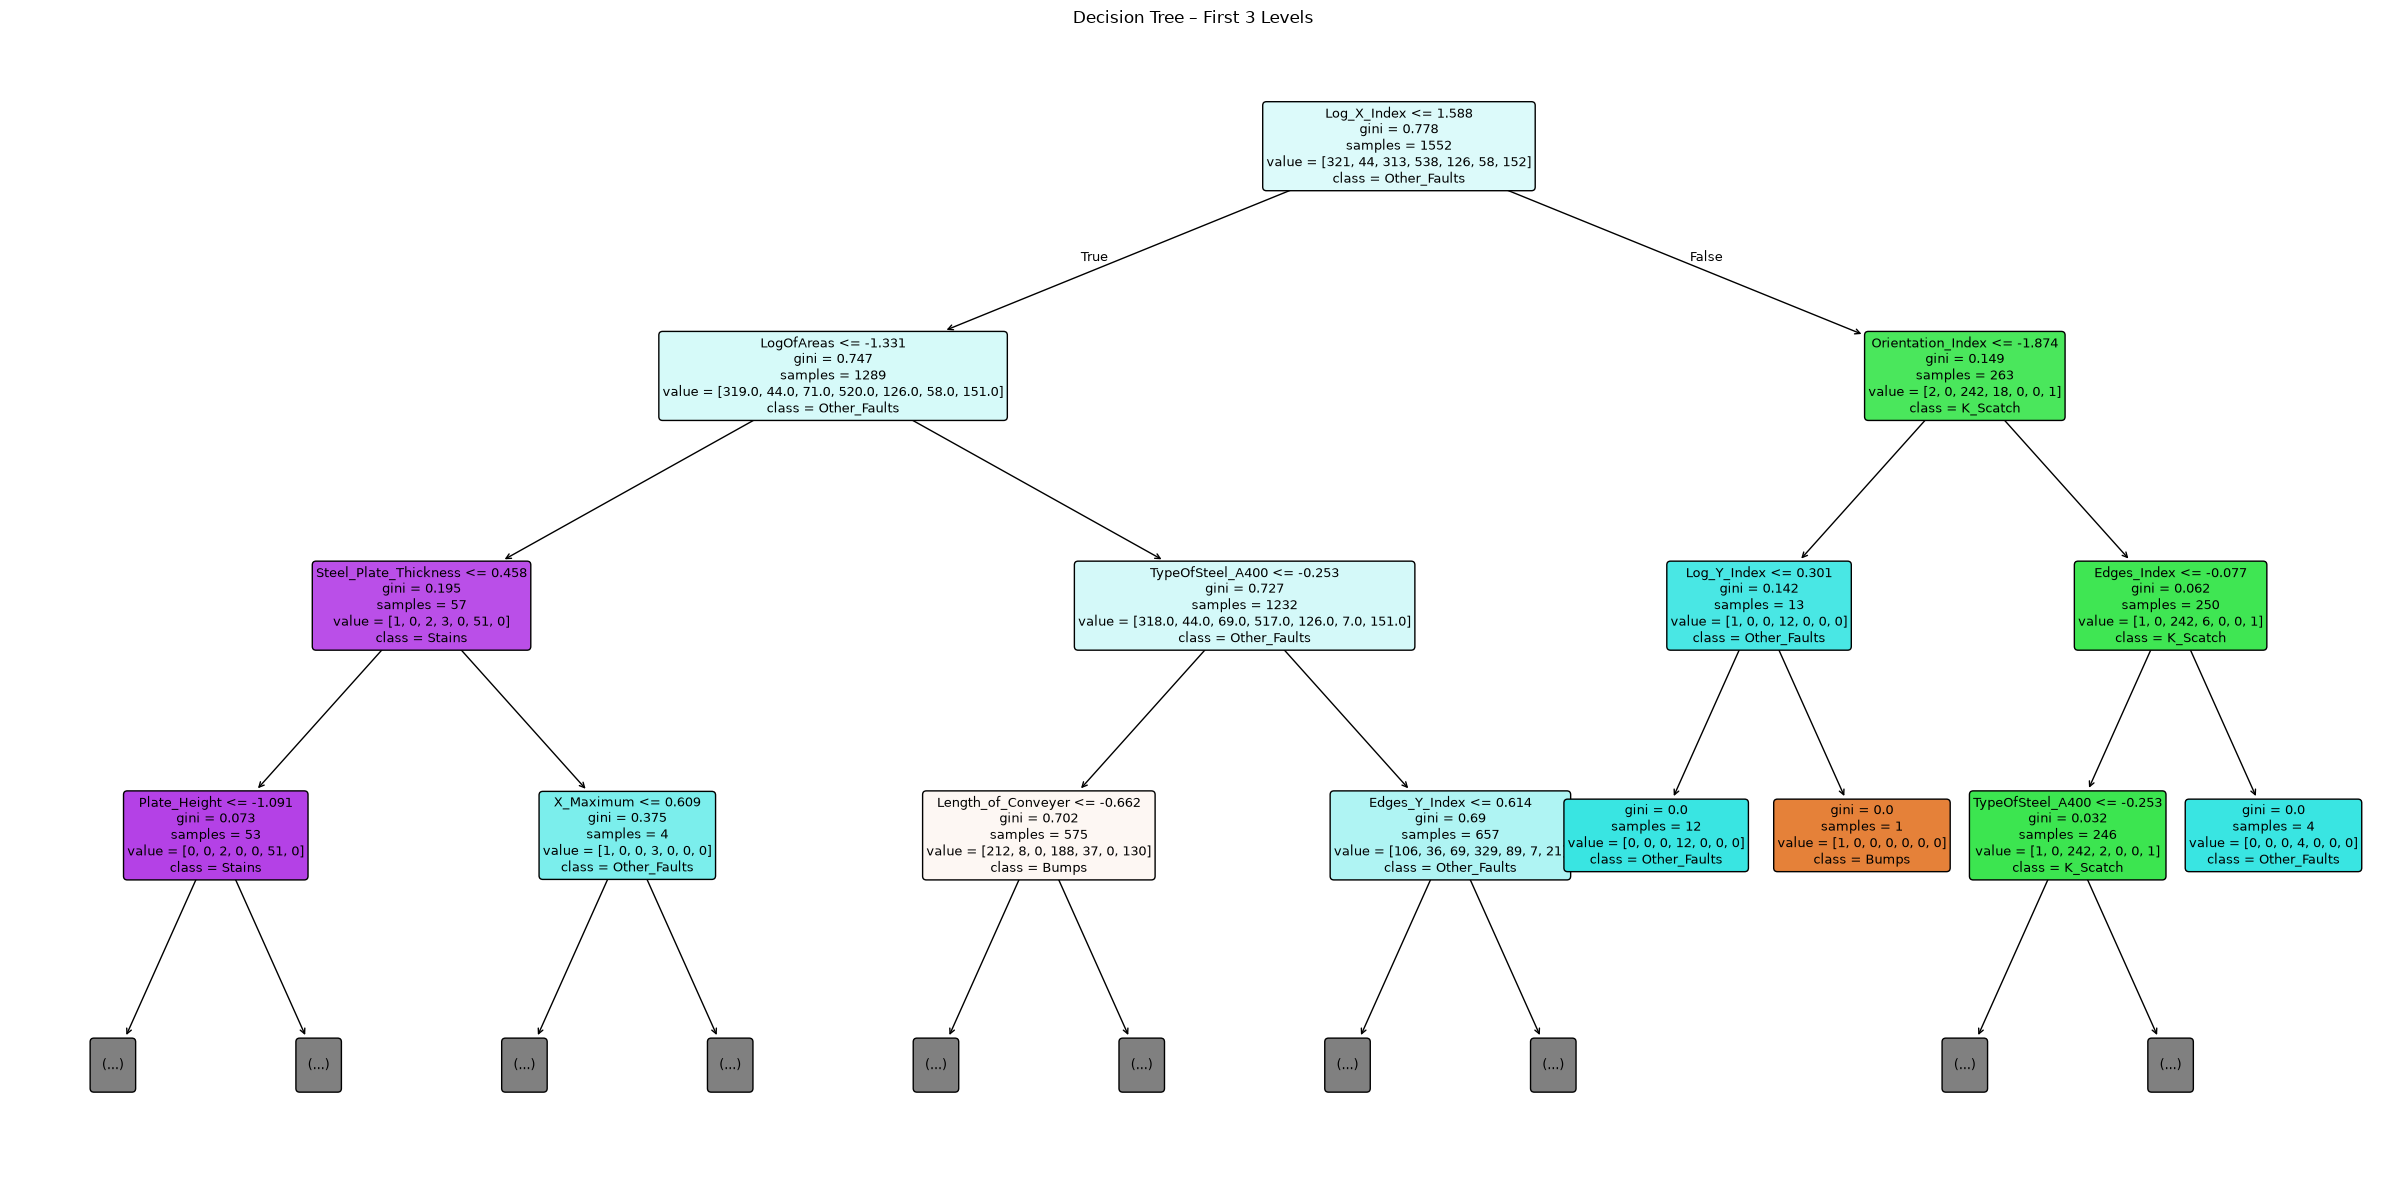

In [4]:
# Decision Tree Visualisation

tree = pipe.named_steps["classifier"]

feature_names = (
    pipe
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

plt.figure(figsize=(24, 12))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree – First 3 Levels")

plt.tight_layout()
plt.show()

### Observation
The initial tree levels depict the way splits based on thresholds create clusters of data associated with different types of faults. The restriction to only three levels of the tree allows making the picture comprehensible for the viewer.